# P2 - Trajectory Coverage

This notebook documents the method used in SimLab for **Problem P2: discrete coverage with mobility**. The content is aligned with the current implementation in the `simlab` repository, especially the modules:

- `mo-engine/lib/problem/p2_discrete_mobility.py`
- `mo-engine/lib/util/trajectory_sampling.py`
- `mo-engine/lib/util/random_network.py`
- `mo-engine/lib/util/connectivity.py`
- `mo-engine/lib/problem/docs/Rooted stochastic expansion over the reachability graph.md`
- `mo-engine/lib/problem/docs/Connectivity Repair via Rooted Growth.md`

The goal is to make explicit how trajectory coverage is computed and how the repair algorithm fixes binary masks that lose connectivity after crossover or mutation.

## P2 Formulation

In P2, relay positions are not continuous. There is a fixed set of candidate positions:

- `Q = {q_0, q_1, ..., q_{J-1}}`: candidate positions where relays may be installed;
- `S`: fixed sink position;
- `R`: communication/coverage radius (`radius_of_reach`);
- `Gamma`: set of mobile-node trajectories;
- `p_min`: required minimum coverage percentage (`min_coverage_percentage`).

The P2 chromosome has two gene types:

- a **binary mask** `x in {0,1}^J`, where `x[j] = 1` means candidate `q_j` is activated as a relay;
- a MAC protocol gene, encoded as a binary value, for example CSMA/TSCH.

Thus, a solution selects a subset `P` of active candidates, where `P = {q_j in Q | x[j] = 1}`. The solution must remain connected to the sink and cover the mobile trajectories above the configured threshold.

## Trajectory Coverage Method

Coverage is evaluated discretely. Instead of checking a continuous curve directly, each parametric trajectory is sampled into a finite set of points. In SimLab this is implemented by `sample_trajectories`.

Each trajectory segment is described by parametric expressions `(x(t), y(t))`, with `t in [0, 1]`. For each segment:

1. the arc length is numerically estimated using a reference grid;
2. the number of samples is chosen proportionally to that length;
3. the points are generated with approximate maximum spacing `R/2`;
4. the initial and final points of the segment are always included.

The choice `step = R/2` is conservative: it reduces the risk of leaving a gap larger than the coverage radius between consecutive samples. Therefore, if the solution covers all sampled points, the discrete evaluation becomes a practical approximation of continuous trajectory coverage.

## Bitset Coverage Matrix

After sampling the trajectories, SimLab precomputes a coverage matrix in `build_coverage_matrix`. This matrix has one row for each sampled point and one column for each candidate `q_j`.

Conceptually:

```text
M[i, j] = 1  if  dist(sampled_point_i, q_j) <= R
M[i, j] = 0  otherwise
```

In the implementation, each row `M[i]` is stored as a Python integer used as a bitset. Bit `j` is set when candidate `q_j` covers sampled point `i`.

To evaluate a mask `x`, `check_coverage` converts the mask into another bitset and checks each row for intersection:

```text
covered_i = (M[i] AND mask_bits) != 0
score = 100 * covered_count / total_sampled_points
```

Therefore, `score = 100` means every sampled trajectory point is covered by at least one active candidate. `score = 0` means no sampled point was covered.

Important note: in P2, the coverage matrix is built over the candidates `Q`. The sink participates in the connectivity constraint, but it is not included as a column in the trajectory coverage matrix.

## Using the Coverage Score During Evaluation

`Problem2DiscreteMobilityAdapter` builds the coverage matrix once when validating the problem instance. After that, each chromosome can be evaluated by applying its binary mask to this matrix.

The flow is:

1. read the mobile-node trajectories;
2. sample the trajectories with step `R/2`;
3. build the coverage matrix between sampled points and candidates;
4. for each individual, compute `coverage_score(mask)`;
5. compare the score with `min_coverage_percentage`.

When the score is below the minimum threshold, the individual receives a penalty in the objectives instead of being treated as feasible. The penalty used in SimLab grows with the coverage deficit:

```text
deficit = (min_coverage_percentage - score) / 100
penalty = 1e9 * (1 + deficit)
```

Thus, every infeasible individual is dominated by feasible solutions, and individuals with worse coverage receive larger penalties.

## Initial Generation: Rooted Stochastic Growth

The initial P2 population is not created from uniformly random binary masks. SimLab uses `stochastic_reachability_mask`, a growth process on the candidate reachability graph.

A geometric graph is defined over `Q`, where two candidates are adjacent when the distance between them is less than or equal to `R`. Expansion starts from the sink neighborhood: candidates within `R` of the sink may start the relay tree.

Each candidate can be in exactly one of three states:

- `FREE`: not processed yet;
- `SELECTED`: activated in the mask;
- `DISCARDED`: rejected and removed from the process.

The active frontier contains selected candidates that may still expand the solution. For each frontier node, the algorithm randomly chooses a number of reachable free neighbors, activates that subset, and discards the remaining free neighbors of that node.

This design generates connected and relatively sparse masks, avoiding collapse into solutions where all candidates are active.

### Initial Generation Pseudocode

```text
Input: candidates Q, sink S, radius R
Output: binary mask x

FREE = all candidate indices
SELECTED = empty set
DISCARDED = empty set
frontier = empty set

reachable_from_sink = {i in FREE | dist(S, q_i) <= R}

if reachable_from_sink is not empty:
    c = random integer in [1, |reachable_from_sink|]
    chosen = random subset of reachable_from_sink with size c
    rejected = reachable_from_sink - chosen

    SELECTED += chosen
    frontier += chosen
    FREE -= chosen
    FREE -= rejected
    DISCARDED += rejected

while frontier is not empty and FREE is not empty:
    u = pop random/iteration element from frontier
    reachable = {v in FREE | dist(q_u, q_v) <= R}

    if reachable is empty:
        continue

    c = random integer in [1, |reachable|]
    chosen = random subset of reachable with size c
    rejected = reachable - chosen

    SELECTED += chosen
    frontier += chosen
    FREE -= chosen
    FREE -= rejected
    DISCARDED += rejected

x[j] = 1 iff j in SELECTED
```

Connectivity is preserved by construction: every selected candidate added after initialization is reachable from a candidate that already belonged to the solution.

## Why Repair Is Needed

Even if initial generation produces connected masks, genetic operators can break this property:

- **uniform crossover** recombines bits independently and may separate previously connected components;
- **bit-flip mutation** may disable critical relays or enable isolated candidates.

For this reason, in P2 every offspring produced by crossover or mutation is passed through `repair_connectivity_to_sink`. If repair fails, SimLab restores the original mask or the corresponding parent mask, avoiding the evaluation of disconnected individuals.

## Repair Algorithm: Connectivity Repair via Rooted Growth

The repair operates on the binary mask and on the full candidate reachability graph. The idea is to transform a possibly invalid mask into a mask connected to the sink, activating a heuristically small number of intermediate candidates.

The notion of minimum is heuristic rather than exact: the algorithm does not solve a MILP and does not compute an optimal Steiner tree. It uses shortest paths in number of hops in the reachability graph. This is lightweight, fast, and suitable for repeated calls inside the evolutionary loop.

Main steps:

1. build the full graph `G(Q, E)`, with edge `(i, j)` when `dist(q_i, q_j) <= R`;
2. consider only the active candidates in the current mask;
3. identify the connected components induced by active candidates;
4. locate the component connected to the sink, that is, the component containing at least one active candidate at distance `<= R` from the sink;
5. while disconnected components remain, choose one and find a shortest path in the full graph between the sink component and that component;
6. activate every candidate along this path;
7. recompute the components and repeat until everything is connected to the sink.

The result is a repaired mask. The nodes activated during repair act as intermediate relays that stitch disconnected components together.

### Repair Pseudocode

```text
Input: candidates Q, mask x, sink S, radius R
Output: error flag, repaired mask x'

x' = copy(x)
G = full reachability graph over Q

while true:
    components = connected components induced by active nodes in x'

    if components is empty:
        return success, x'

    sink_component = active nodes that are within R of S,
                     expanded through active edges

    if every active component intersects sink_component:
        return success, x'

    C = one active component not connected to sink_component

    path = shortest path in G from any node in sink_component
           to any node in C

    if no path exists:
        return error, empty mask

    activate every candidate index on path in x'
```

This procedure approximates a Steiner-tree construction on a discrete geometric graph: it connects components through short paths and reuses already active paths whenever possible.

## P2 Genetic Operator Flow

The flow implemented in `Problem2DiscreteMobilityAdapter` can be summarized as:

```text
Initialization:
    stochastic_reachability_mask(Q, S, R)
        -> mask connected to the sink

Crossover:
    uniform_crossover_mask(parent_1.mask, parent_2.mask)
        -> repair_connectivity_to_sink(Q, child_mask, S, R)
        -> if it fails, restore the corresponding parent mask

Mutation:
    bitflip_mutation(mask, p_bit)
        -> repair_connectivity_to_sink(Q, mutated_mask, S, R)
        -> if it fails, restore the original mask

Evaluation:
    coverage_score(mask)
        -> if score < min_coverage_percentage, apply penalty
        -> otherwise, encode the simulation input for Cooja
```

With this design, P2 separates two responsibilities: connectivity is preserved/repaired by the genetic operators, while trajectory coverage is evaluated by a precomputed matrix and converted into a penalty when necessary.

## Practical Interpretation

The combination used by SimLab has three important consequences:

1. **Low computational cost:** the coverage matrix is built once, and each evaluation uses fast bitset operations.
2. **More stable search:** individuals tend to remain connected to the sink after initialization, crossover, and mutation.
3. **Clear evolutionary pressure:** solutions that reduce the number of relays, improve simulated objectives, and satisfy the coverage threshold are favored; solutions below the threshold receive a penalty proportional to the deficit.

In summary, P2 avoids searching directly in the continuous position space. It searches in the discrete candidate space, using binary masks, a bitset coverage matrix, and rooted-growth repair to maintain structural feasibility.

## Executable Demonstrations

The cells below build a small scenario to visualize how P2 works. The example uses a sinusoidal trajectory, a discrete grid of candidates, an active mask, the coverage matrix, and an artificial case where connectivity must be repaired.

In [1]:
import math
import random
from collections import deque

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

R = 22.0
SINK = (0.0, 0.0)
REGION = (-10.0, -35.0, 130.0, 45.0)
TRAJECTORY_SEGMENTS = [("120 * t", "18 * np.sin(2 * np.pi * t)")]
CANDIDATES = [(float(x), float(y)) for x in range(0, 121, 20) for y in (-20, 0, 20)]


def eval_expr(expr, t):
    return float(eval(expr, {"np": np, "t": float(t)}))


def arc_length(x_expr, y_expr, ref_samples=500):
    t_values = np.linspace(0.0, 1.0, ref_samples)
    points = np.array([(eval_expr(x_expr, t), eval_expr(y_expr, t)) for t in t_values])
    diffs = np.diff(points, axis=0)
    return float(np.sum(np.hypot(diffs[:, 0], diffs[:, 1])))


def sample_segments(path_segments, step):
    sampled = []
    for x_expr, y_expr in path_segments:
        length = arc_length(x_expr, y_expr)
        n_points = max(2, math.ceil(length / step) + 1)
        for t in np.linspace(0.0, 1.0, n_points):
            sampled.append((eval_expr(x_expr, t), eval_expr(y_expr, t)))
    return sampled


def build_coverage_matrix(sampled_points, candidates, radius):
    radius_sq = radius * radius
    matrix = []
    for sx, sy in sampled_points:
        row = 0
        for j, (cx, cy) in enumerate(candidates):
            dx = sx - cx
            dy = sy - cy
            if dx * dx + dy * dy <= radius_sq:
                row |= 1 << j
        matrix.append(row)
    return matrix


def mask_to_bits(mask):
    bits = 0
    for j, bit in enumerate(mask):
        if bit:
            bits |= 1 << j
    return bits


def check_coverage(matrix, mask):
    if not matrix:
        return 100.0
    mask_bits = mask_to_bits(mask)
    covered = sum(1 for row in matrix if row & mask_bits)
    return 100.0 * covered / len(matrix)


SAMPLED_POINTS = sample_segments(TRAJECTORY_SEGMENTS, step=R / 2)
COVERAGE_MATRIX = build_coverage_matrix(SAMPLED_POINTS, CANDIDATES, R)
ACTIVE_MASK = [0, 1, 0, 
               0, 1, 0, 
               0, 0, 1, 
               0, 1, 0, 
               0, 1, 0, 
               1, 0, 0, 
               0, 1, 0]
score = check_coverage(COVERAGE_MATRIX, ACTIVE_MASK)

print(f"Trajectory samples: {len(SAMPLED_POINTS)}")
print(f"Candidates: {len(CANDIDATES)}")
print(f"Active relays: {sum(ACTIVE_MASK)}")
print(f"Discrete coverage: {score:.1f}%")

Trajectory samples: 15
Candidates: 21
Active relays: 7
Discrete coverage: 100.0%


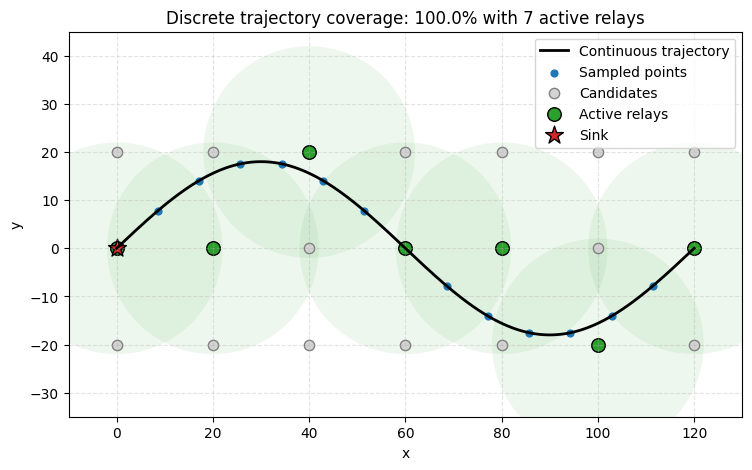

In [2]:
fig, ax = plt.subplots(figsize=(11, 5))

t_dense = np.linspace(0.0, 1.0, 400)
curve = np.array([
    (eval_expr(TRAJECTORY_SEGMENTS[0][0], t), eval_expr(TRAJECTORY_SEGMENTS[0][1], t))
    for t in t_dense
])
sampled = np.array(SAMPLED_POINTS)
candidates = np.array(CANDIDATES)
active = np.array([CANDIDATES[i] for i in range(len(CANDIDATES)) if ACTIVE_MASK[i]])

for x, y in active:
    ax.add_patch(Circle((x, y), R, color="tab:green", alpha=0.08, linewidth=0))

ax.plot(curve[:, 0], curve[:, 1], color="black", linewidth=2.0, label="Continuous trajectory")
ax.scatter(sampled[:, 0], sampled[:, 1], s=24, color="tab:blue", label="Sampled points")
ax.scatter(candidates[:, 0], candidates[:, 1], s=55, color="lightgray", edgecolor="gray", label="Candidates")
ax.scatter(active[:, 0], active[:, 1], s=95, color="tab:green", edgecolor="black", label="Active relays")
ax.scatter([SINK[0]], [SINK[1]], s=180, marker="*", color="tab:red", edgecolor="black", label="Sink")

ax.set_xlim(REGION[0], REGION[2])
ax.set_ylim(REGION[1], REGION[3])
ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.35)
ax.set_title(f"Discrete trajectory coverage: {score:.1f}% with {sum(ACTIVE_MASK)} active relays")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper right")
plt.show()

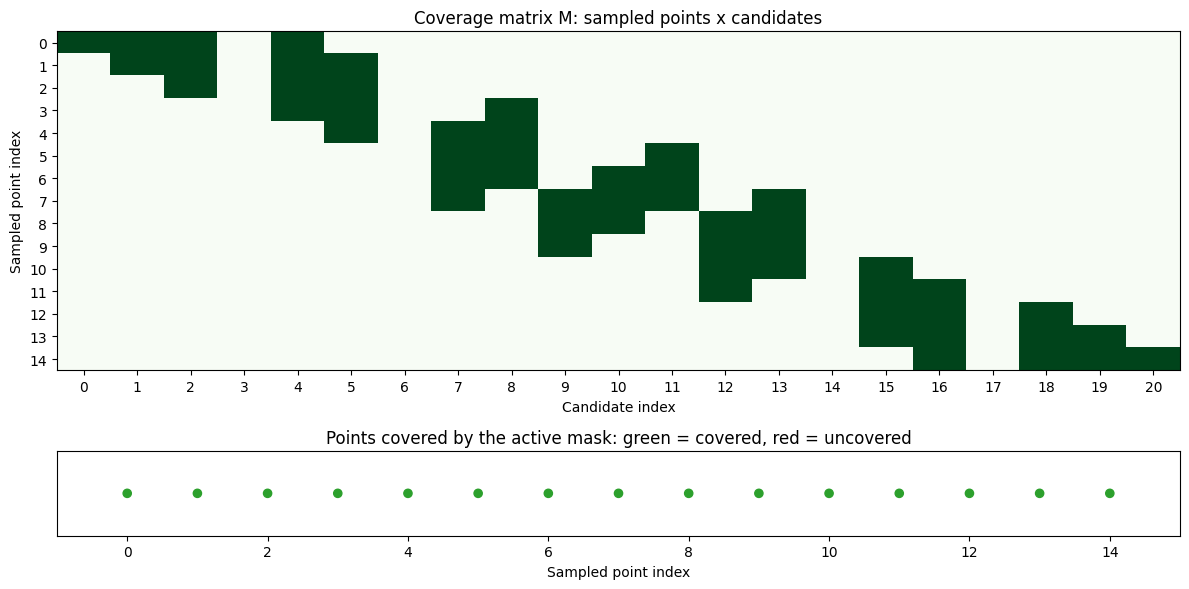

In [3]:
matrix_bits = np.array([
    [(row >> j) & 1 for j in range(len(CANDIDATES))]
    for row in COVERAGE_MATRIX
], dtype=int)
mask_bits = mask_to_bits(ACTIVE_MASK)
covered_flags = np.array([bool(row & mask_bits) for row in COVERAGE_MATRIX])

fig, (ax_matrix, ax_flags) = plt.subplots(
    2, 1, figsize=(12, 6), gridspec_kw={"height_ratios": [4, 1]}, sharex=False
)

im = ax_matrix.imshow(matrix_bits, aspect="auto", interpolation="nearest", cmap="Greens")
ax_matrix.set_title("Coverage matrix M: sampled points x candidates")
ax_matrix.set_ylabel("Sampled point index")
ax_matrix.set_xlabel("Candidate index")
ax_matrix.set_xticks(range(len(CANDIDATES)))
ax_matrix.set_yticks(range(0, len(SAMPLED_POINTS), max(1, len(SAMPLED_POINTS) // 8)))

colors = np.where(covered_flags, "tab:green", "tab:red")
ax_flags.scatter(range(len(SAMPLED_POINTS)), np.zeros(len(SAMPLED_POINTS)), c=colors, s=35)
ax_flags.set_yticks([])
ax_flags.set_xlim(-1, len(SAMPLED_POINTS))
ax_flags.set_title("Points covered by the active mask: green = covered, red = uncovered")
ax_flags.set_xlabel("Sampled point index")

plt.tight_layout()
plt.show()

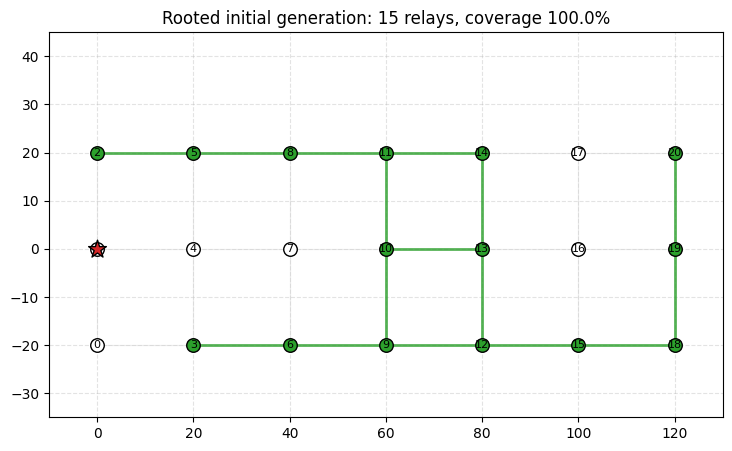

In [6]:
def dist(p, q):
    return math.hypot(p[0] - q[0], p[1] - q[1])


def stochastic_reachability_mask(candidates, sink, radius, rng):
    n = len(candidates)
    free = set(range(n))
    selected = set()
    discarded = set()
    frontier = set()

    reachable_from_sink = [i for i in free if dist(sink, candidates[i]) <= radius]
    if reachable_from_sink:
        c = rng.randint(1, len(reachable_from_sink))
        chosen = set(rng.sample(reachable_from_sink, c))
        rejected = set(reachable_from_sink) - chosen
        selected.update(chosen)
        frontier.update(chosen)
        free.difference_update(chosen)
        free.difference_update(rejected)
        discarded.update(rejected)

    while frontier and free:
        u = frontier.pop()
        reachable = [v for v in free if dist(candidates[u], candidates[v]) <= radius]
        if not reachable:
            continue
        c = rng.randint(1, len(reachable))
        chosen = set(rng.sample(reachable, c))
        rejected = set(reachable) - chosen
        selected.update(chosen)
        frontier.update(chosen)
        free.difference_update(chosen)
        free.difference_update(rejected)
        discarded.update(rejected)

    return [1 if i in selected else 0 for i in range(n)]


def plot_mask_graph(ax, mask, title):
    for i, p in enumerate(CANDIDATES):
        for j in range(i + 1, len(CANDIDATES)):
            q = CANDIDATES[j]
            if dist(p, q) <= R:
                active_edge = mask[i] == 1 and mask[j] == 1
                ax.plot([p[0], q[0]], [p[1], q[1]], color="tab:green" if active_edge else "lightgray", linewidth=2.0 if active_edge else 0.8, alpha=0.8 if active_edge else 0.45)
    for i, (x, y) in enumerate(CANDIDATES):
        color = "tab:green" if mask[i] else "white"
        ax.scatter([x], [y], s=95, color=color, edgecolor="black", zorder=3)
        ax.text(x, y, str(i), ha="center", va="center", fontsize=8, zorder=4)
    ax.scatter([SINK[0]], [SINK[1]], s=180, marker="*", color="tab:red", edgecolor="black", zorder=5)
    ax.set_xlim(REGION[0], REGION[2])
    ax.set_ylim(REGION[1], REGION[3])
    ax.set_aspect("equal")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.set_title(title)


rng = random.Random(123)
generated_mask = stochastic_reachability_mask(CANDIDATES, SINK, R, rng)
generated_score = check_coverage(COVERAGE_MATRIX, generated_mask)

fig, ax = plt.subplots(figsize=(11, 5))
plot_mask_graph(ax, generated_mask, f"Rooted initial generation: {sum(generated_mask)} relays, coverage {generated_score:.1f}%")
plt.show()

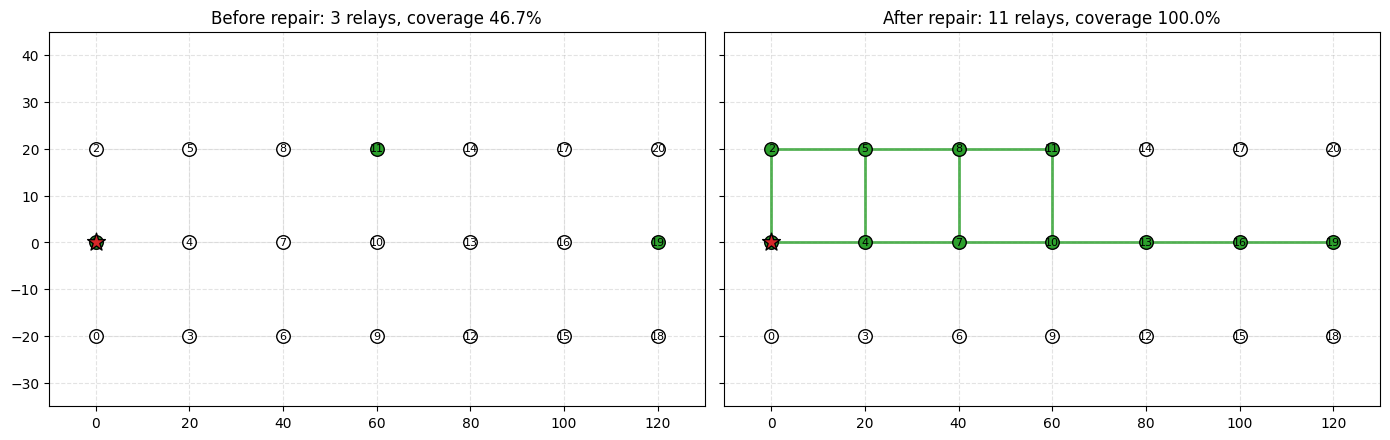

Did repair fail? False
Relays added by repair: 8


In [5]:
def repair_connectivity_to_sink(candidates, mask, sink, radius):
    n = len(candidates)
    repaired = mask[:]

    adj = [[] for _ in range(n)]
    for i in range(n):
        for j in range(i + 1, n):
            if dist(candidates[i], candidates[j]) <= radius:
                adj[i].append(j)
                adj[j].append(i)

    def active_components():
        visited = set()
        components = []
        for i in range(n):
            if repaired[i] != 1 or i in visited:
                continue
            comp = set()
            queue = deque([i])
            visited.add(i)
            while queue:
                u = queue.popleft()
                comp.add(u)
                for v in adj[u]:
                    if repaired[v] == 1 and v not in visited:
                        visited.add(v)
                        queue.append(v)
            components.append(comp)
        return components

    while True:
        components = active_components()
        if not components:
            return False, repaired

        sink_comp = {i for i in range(n) if repaired[i] == 1 and dist(sink, candidates[i]) <= radius}
        if not sink_comp:
            closest = min((i for i in range(n) if repaired[i] == 1), key=lambda i: dist(sink, candidates[i]))
            sink_comp.add(closest)

        if all(comp & sink_comp for comp in components):
            return False, repaired

        other_comp = next(comp for comp in components if not (comp & sink_comp))
        queue = deque(sink_comp)
        parent = {u: None for u in sink_comp}
        target = None

        while queue and target is None:
            u = queue.popleft()
            for v in adj[u]:
                if v in parent:
                    continue
                parent[v] = u
                if v in other_comp:
                    target = v
                    break
                queue.append(v)

        if target is None:
            return True, []

        cur = target
        while cur is not None:
            repaired[cur] = 1
            cur = parent[cur]


broken_mask = [0] * len(CANDIDATES)
for idx in [1, 11, 19]:
    broken_mask[idx] = 1

err, repaired_mask = repair_connectivity_to_sink(CANDIDATES, broken_mask, SINK, R)
before_score = check_coverage(COVERAGE_MATRIX, broken_mask)
after_score = check_coverage(COVERAGE_MATRIX, repaired_mask)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
plot_mask_graph(axes[0], broken_mask, f"Before repair: {sum(broken_mask)} relays, coverage {before_score:.1f}%")
plot_mask_graph(axes[1], repaired_mask, f"After repair: {sum(repaired_mask)} relays, coverage {after_score:.1f}%")
plt.tight_layout()
plt.show()

print(f"Did repair fail? {err}")
print(f"Relays added by repair: {sum(repaired_mask) - sum(broken_mask)}")